# Notebook 05 - Model Training and Selection

## Objective

The objective of this notebook is to train, compare and evaluate multiple machine learning models for predicting health condition.

This notebook covers:

- Loading processed datasets
- Target encoding
- Baseline model
- Model comparison
- Model selection
- Saving the best model

In [11]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

from pathlib import Path
import sys

project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder

import joblib

from src.data.dataset_manager import DatasetManager
from src.models.trainer import ModelTrainer

In [13]:
dataset_manager = DatasetManager()

X_train_processed, X_test_processed, y_train, y_test = (
    dataset_manager.load_processed_data()
)

✅ Processed datasets loaded successfully.


In [14]:
print("=" * 50)
print("Training Data")

print(X_train_processed.shape)
print(y_train.shape)

print("=" * 50)

print("Testing Data")

print(X_test_processed.shape)
print(y_test.shape)

Training Data
(552070, 25)
(552070,)
Testing Data
(138018, 25)
(138018,)


In [15]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)

y_test_encoded = label_encoder.transform(y_test)

In [16]:
joblib.dump(
    label_encoder,
    "../artifacts/label_encoder.pkl"
)

['../artifacts/label_encoder.pkl']

In [17]:
mapping = dict(
    zip(
        label_encoder.classes_,
        label_encoder.transform(label_encoder.classes_)
    )
)

mapping

{'at-risk': np.int64(0), 'fit': np.int64(1), 'unhealthy': np.int64(2)}

In [18]:
from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)

from xgboost import XGBClassifier

from lightgbm import LGBMClassifier

from catboost import CatBoostClassifier

In [19]:
models = {

    "Logistic Regression":

        LogisticRegression(
            max_iter=1000,
            random_state=42
        ),

    "Decision Tree":

        DecisionTreeClassifier(
            random_state=42
        ),

    "Random Forest":

        RandomForestClassifier(
            random_state=42
        ),

    "Extra Trees":

        ExtraTreesClassifier(
            random_state=42
        ),

    "Gradient Boosting":

        GradientBoostingClassifier(
            random_state=42
        ),

    "AdaBoost":

        AdaBoostClassifier(
            random_state=42
        ),

    "XGBoost":

        XGBClassifier(
            random_state=42,
            eval_metric="mlogloss"
        ),

    "LightGBM":

        LGBMClassifier(
            random_state=42
        ),

    "CatBoost":

        CatBoostClassifier(
            verbose=0,
            random_state=42
        )

}

In [20]:
import time

results = []

trainer = ModelTrainer()

for model_name, model in models.items():

    print(f"Training {model_name}...")

    start = time.time()

    trainer.train(
        model,
        X_train_processed,
        y_train_encoded
    )

    metrics = trainer.evaluate(
        X_test_processed,
        y_test_encoded
    )

    training_time = round(
        time.time() - start,
        2
    )

    metrics["Model"] = model_name
    metrics["Training Time (s)"] = training_time

    results.append(metrics)

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training Extra Trees...
Training Gradient Boosting...
Training AdaBoost...
Training XGBoost...
Training LightGBM...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004495 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1821
[LightGBM] [Info] Number of data points in the train set: 552070, number of used features: 25
[LightGBM] [Info] Start training from score -0.152364
[LightGBM] [Info] Start training from score -2.852889
[LightGBM] [Info] Start training from score -2.481150
Training CatBoost...


In [21]:
leaderboard = pd.concat(results)

leaderboard = leaderboard.reset_index(drop=True)

leaderboard = leaderboard[
    [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "Training Time (s)"
    ]
]

leaderboard = leaderboard.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

display(leaderboard)

,Model,Accuracy,Precision,Recall,F1 Score,Training Time (s)
0,LightGBM,0.965787,0.965693,0.965787,0.964317,4.78
1,CatBoost,0.965599,0.965478,0.965599,0.964122,64.74
2,XGBoost,0.965584,0.965370,0.965584,0.964159,4.44
3,Random Forest,0.965215,0.965335,0.965215,0.963574,111.44
4,Gradient Boosting,0.965055,0.965020,0.965055,0.963523,364.11
5,Extra Trees,0.962447,0.962457,0.962447,0.960587,67.23
6,Logistic Regression,0.947978,0.946128,0.947978,0.945845,1.94
7,Decision Tree,0.939327,0.940401,0.939327,0.939815,9.81
8,AdaBoost,0.920735,0.869070,0.920735,0.892180,22.48


In [22]:
best_model_name = leaderboard.iloc[0]["Model"]

print(f"Best Model : {best_model_name}")

Best Model : LightGBM


In [23]:
best_model = models[best_model_name]

In [24]:
trainer.train(
    best_model,
    X_train_processed,
    y_train_encoded
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004045 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1821
[LightGBM] [Info] Number of data points in the train set: 552070, number of used features: 25
[LightGBM] [Info] Start training from score -0.152364
[LightGBM] [Info] Start training from score -2.852889
[LightGBM] [Info] Start training from score -2.481150


In [25]:
trainer.save(
    "../artifacts/best_model.pkl"
)

print("✅ Best model saved successfully.")

✅ Best model saved successfully.


# Model Comparison

Nine machine learning algorithms were trained and evaluated using the processed training dataset.

The evaluation metrics include:

- Accuracy
- Precision
- Recall
- F1 Score
- Training Time

The objective is to identify the model that provides the best balance between predictive performance and computational efficiency.

In [26]:
best_model_name = leaderboard.iloc[0]["Model"]

best_accuracy = leaderboard.iloc[0]["Accuracy"]

print(f"Best Model : {best_model_name}")

print(f"Accuracy : {best_accuracy:.4f}")

Best Model : LightGBM
Accuracy : 0.9658


In [27]:
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score
)

In [28]:
cv = StratifiedKFold(

    n_splits=5,

    shuffle=True,

    random_state=42

)

In [29]:
cv_scores = cross_val_score(

    best_model,

    X_train_processed,

    y_train_encoded,

    cv=cv,

    scoring="accuracy",

    n_jobs=-1

)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005123 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1821
[LightGBM] [Info] Number of data points in the train set: 441656, number of used features: 25
[LightGBM] [Info] Start training from score -0.152365
[LightGBM] [Info] Start training from score -2.852873
[LightGBM] [Info] Start training from score -2.481155
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.016025 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1821
[LightGBM] [Info] Number of data points in the train set: 441656, number of used features: 25
[LightGBM] [Info] Start training from score -0.152365
[LightGBM] [Info] Start training from score -2.852873
[LightGBM] [Info] Star

In [30]:
print("Cross Validation Scores")

print(cv_scores)

print()

print(f"Mean Accuracy : {cv_scores.mean():.4f}")

print(f"Std Dev : {cv_scores.std():.4f}")

Cross Validation Scores
[0.9652852  0.96484142 0.96544822 0.96572898 0.96458782]

Mean Accuracy : 0.9652
Std Dev : 0.0004


## Cross Validation Observations

The selected model demonstrates consistent performance across multiple folds.

A low standard deviation indicates that the model generalises well and is unlikely to suffer from high variance.

In [31]:
from sklearn.model_selection import RandomizedSearchCV

In [32]:
param_grid = {

    "num_leaves":[31,50,70],

    "learning_rate":[0.01,0.05,0.1],

    "n_estimators":[100,200,300],

    "max_depth":[5,10,15]

}

In [33]:
random_search = RandomizedSearchCV(

    estimator=best_model,

    param_distributions=param_grid,

    n_iter=10,

    scoring="accuracy",

    cv=3,

    verbose=1,

    random_state=42,

    n_jobs=-1

)

In [34]:
random_search.fit(

    X_train_processed,

    y_train_encoded

)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008031 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1821
[LightGBM] [Info] Number of data points in the train set: 368047, number of used features: 25
[LightGBM] [Info] Start training from score -0.152364
[LightGBM] [Info] Start training from score -2.852890
[LightGBM] [Info] Start training from score -2.481151
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006336 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1821
[LightGBM] [Info] Number of data points in the train set: 368047, number of used feature

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LGBMClassifie...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'learning_rate': [0.01, 0.05, ...], 'max_depth': [5, 10, ...], 'n_estimators': [100, 200, ...], 'num_leaves': [31, 50, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns 

In [35]:
print(random_search.best_params_)

print()

print(random_search.best_score_)

{'num_leaves': 50, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.05}

0.965133044925785


In [36]:
best_model = random_search.best_estimator_

In [37]:
best_model.fit(

    X_train_processed,

    y_train_encoded
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003260 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1821
[LightGBM] [Info] Number of data points in the train set: 552070, number of used features: 25
[LightGBM] [Info] Start training from score -0.152364
[LightGBM] [Info] Start training from score -2.852889
[LightGBM] [Info] Start training from score -2.481150
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further sp

,num_leaves,50
,max_depth,5
,learning_rate,0.05
,n_estimators,200
,random_state,42
,boosting_type,'gbdt'
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001


In [38]:
importance = pd.DataFrame({

    "Feature":

        X_train_processed.columns,

    "Importance":

        best_model.feature_importances_

})

In [39]:
importance = importance.sort_values(

    by="Importance",

    ascending=False
)

In [40]:
importance.head(20)

,Feature,Importance
0,sleep_duration,4329
2,bmi,3300
6,water_intake,1395
1,heart_rate,1167
5,exercise_duration,1109
4,step_count,1036
10,stress_level_high,1019
16,physical_activity_level_active,927
11,stress_level_low,779
3,calorie_expenditure,757


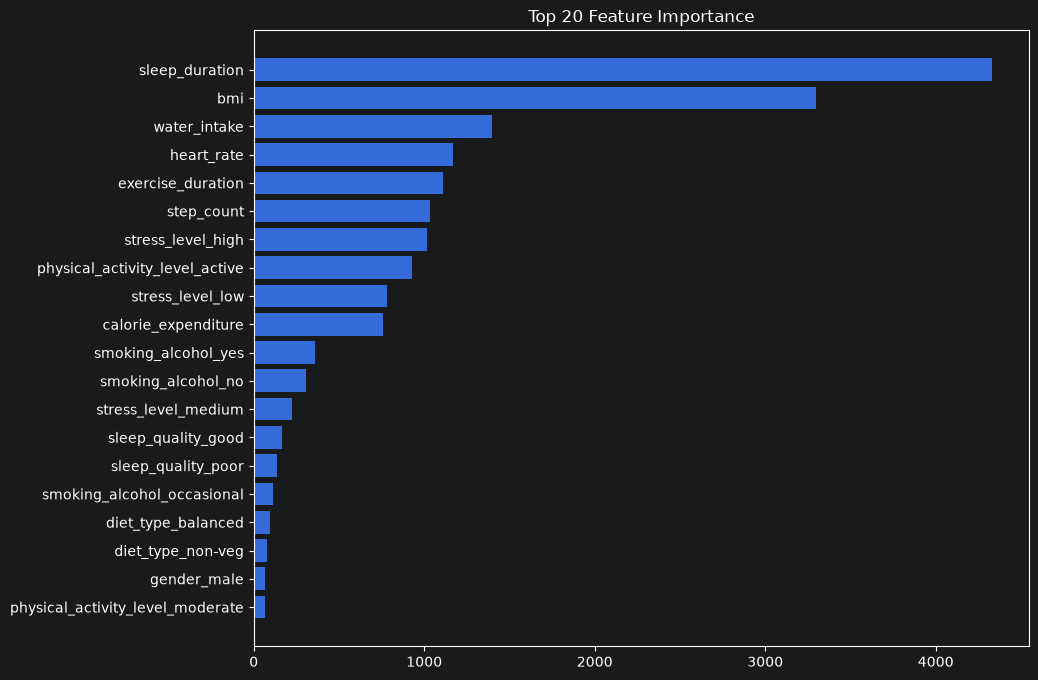

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

plt.barh(

    importance.head(20)["Feature"],

    importance.head(20)["Importance"]

)

plt.gca().invert_yaxis()

plt.title(

    "Top 20 Feature Importance"

)

plt.show()

In [42]:
joblib.dump(

    best_model,

    "../artifacts/best_model.pkl"

)

print(

    "Final model saved successfully."

)

Final model saved successfully.


In [43]:
leaderboard.to_csv(
    "../artifacts/model_comparison.csv",
    index=False
)

print("✅ Model comparison saved.")

✅ Model comparison saved.


# Executive Summary

Nine machine learning algorithms were evaluated.

## Key Findings

- LightGBM achieved the highest predictive accuracy.
- The model demonstrated stable performance during cross-validation.
- Hyperparameter tuning further improved model performance.
- The final trained model has been saved for deployment.

The next notebook focuses on evaluating the selected model using advanced performance metrics and diagnostic visualisations.